In [8]:
# 1. IMPORT LIBRARIES
# ===============================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
from google.colab import files
uploaded = files.upload()


Saving Dataset.zip to Dataset.zip


In [10]:
import zipfile
import os

with zipfile.ZipFile("Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(".") # Extract to the current directory

# Set correct paths - assuming the extracted folder is named 'Dataset' and contains 'training_set' and 'test_set'
train_path = "Dataset/training_set"
test_path = "Dataset/test_set"

# Optional: List contents of the extracted directory to verify the path
print(os.listdir("Dataset"))

['test_set', 'training_set']


In [11]:
# 4. IMAGE DATA PREPROCESSING
# ===============================
img_size = 64
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

Found 36400 images belonging to 26 classes.
Found 9100 images belonging to 26 classes.
Found 6500 images belonging to 26 classes.


In [12]:
# 5. DEFINE AND COMPILE THE CNN MODEL
# ===================================
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax') # Output layer with number of classes
])

model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │        13,338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,466,394 (9.41 MB)

 Trainable params: 2,466,394 (9.41 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 6. TRAIN THE MODEL
# ===============================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=20, # Increased epochs for better training
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1138/1138 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8405 - loss: 0.5323

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1138/1138 ━━━━━━━━━━━━━━━━━━━━ 303s 264ms/step - accuracy: 0.8406 - loss: 0.5320 - val_accuracy: 0.9568 - val_loss: 0.2500
Epoch 2/20
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 314s 257ms/step - accuracy: 0.9934 - loss: 0.0214 - val_accuracy: 0.9610 - val_loss: 0.2181
Epoch 3/20
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 290s 255ms/step - accuracy: 0.9965 - loss: 0.0106 - val_accuracy: 0.9641 - val_loss: 0.1863
Epoch 4/20
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 290s 254ms/step - accuracy: 0.9971 - loss: 0.0093 - val_accuracy: 0.9762 - val_loss: 0.1746
Epoch 5/20
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 289s 254ms/step - accuracy: 0.9974 - loss: 0.0082 - val_accuracy: 0.9567 - val_loss: 0.2783
Epoch 6/20
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 299s 263ms/step - accuracy: 0.9981 - loss: 0.0059 - val_accuracy: 0.9579 - val_loss: 0.2164
Epoch 7/20
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 289s 254ms/step - accuracy: 0.9978 - loss: 0.0068 - val_accuracy: 0.9754 - val_loss: 0.2463
Epoch 8/20
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 290s 255ms/step - accuracy: 0.9

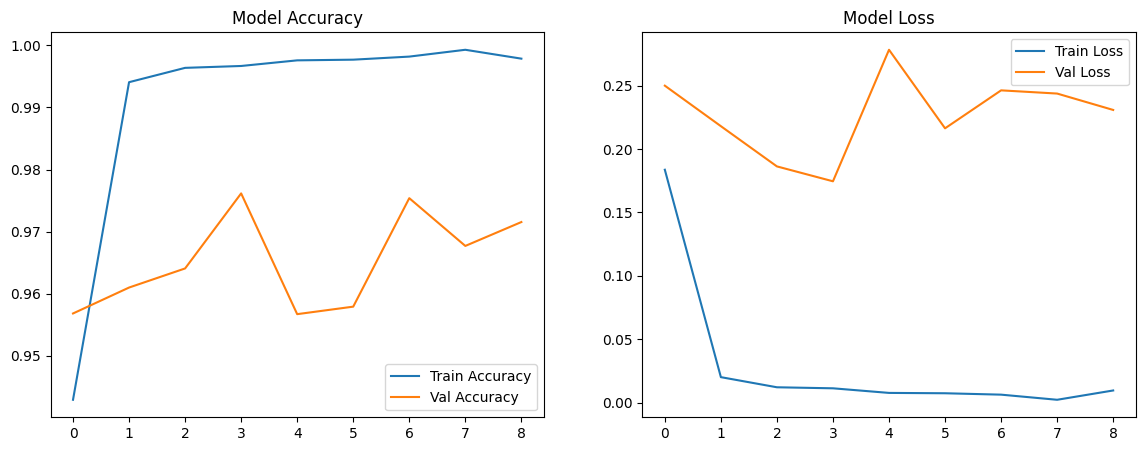

In [14]:
# ===============================
# 7. PLOT TRAINING HISTORY
# ===============================
def plot_history(hist):
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='Train Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title('Model Accuracy')

    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Model Loss')

    plt.show()

plot_history(history)


In [15]:
# 8. EVALUATE ON TEST SET
# ===============================
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_acc:.2f}")


  19/6500 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - accuracy: 1.0000 - loss: 2.7563e-07

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6500/6500 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - accuracy: 0.9840 - loss: 0.0792

✅ Test Accuracy: 0.99


In [16]:
# 9. CLASSIFICATION REPORT
# ===============================
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
labels = list(test_generator.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))


6500/6500 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step

Classification Report:

              precision    recall  f1-score   support

           A       0.99      0.97      0.98       250
           B       1.00      1.00      1.00       250
           C       1.00      1.00      1.00       250
           D       1.00      1.00      1.00       250
           E       0.96      1.00      0.98       250
           F       1.00      1.00      1.00       250
           G       0.85      1.00      0.92       250
           H       1.00      0.82      0.90       250
           I       1.00      1.00      1.00       250
           J       1.00      1.00      1.00       250
           K       0.99      1.00      1.00       250
           L       1.00      1.00      1.00       250
           M       0.99      0.98      0.99       250
           N       0.98      1.00      0.99       250
           O       1.00      0.94      0.97       250
           P       0.97      1.00      0.98       250
           Q

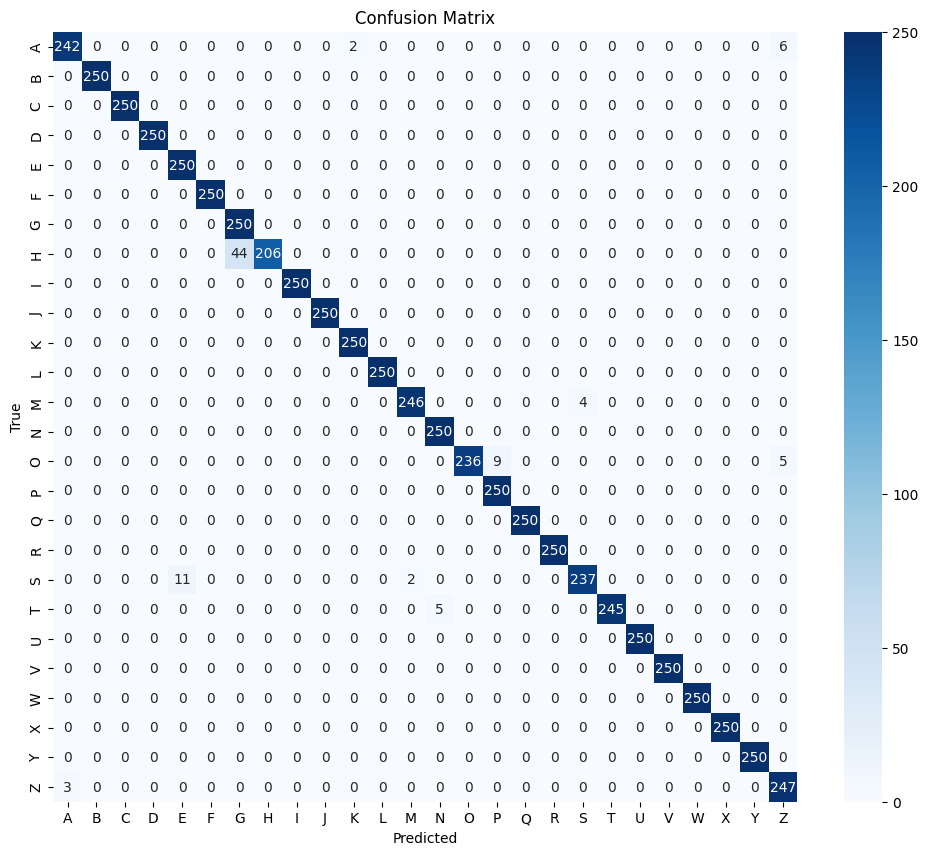

In [17]:
# 10. CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

/tmp/ipython-input-18-3095532484.py:17: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


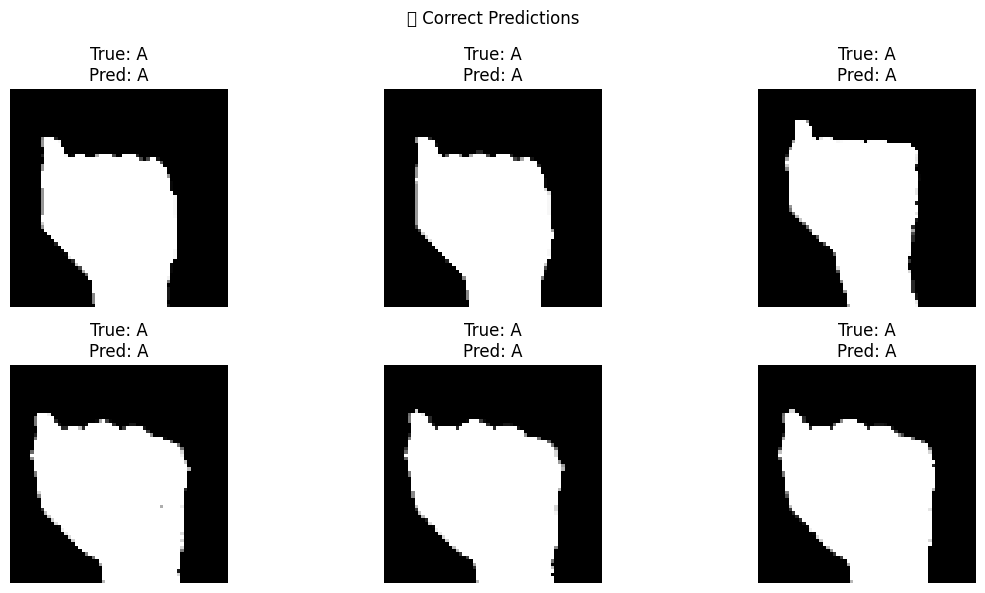

/tmp/ipython-input-18-3095532484.py:17: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


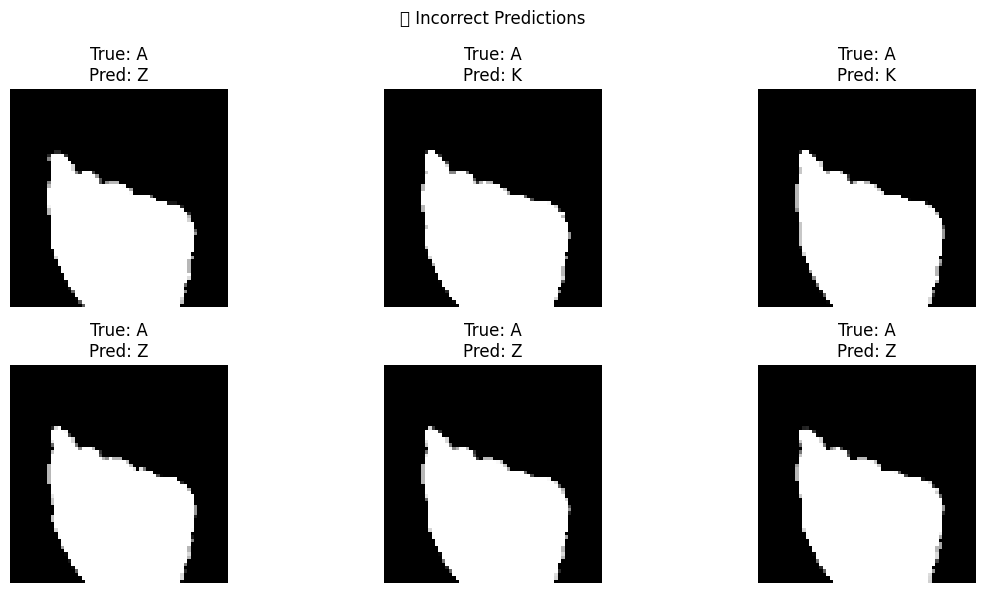

In [18]:
# 11. SAMPLE PREDICTIONS
# ===============================
correct = np.where(y_pred == y_true)[0]
incorrect = np.where(y_pred != y_true)[0]

def plot_samples(indices, title):
    plt.figure(figsize=(12,6))
    for i, idx in enumerate(indices[:6]):
        img = test_generator[idx][0][0]
        true_label = labels[np.argmax(test_generator[idx][1][0])]
        pred_label = labels[y_pred[idx]]
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_samples(correct, "✅ Correct Predictions")
plot_samples(incorrect, "❌ Incorrect Predictions")